In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:

df = pd.read_csv("netflix_titles.csv")
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

In [8]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [9]:
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [10]:
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [11]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [12]:
df['date_added'].dtypes

dtype('O')

In [13]:
df['date_added'].head(10)

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
5    September 24, 2021
6    September 24, 2021
7    September 24, 2021
8    September 24, 2021
9    September 24, 2021
Name: date_added, dtype: object

In [14]:
df['date_added'].tail(10)

8797    September 13, 2018
8798     December 31, 2019
8799     February 15, 2018
8800     December 15, 2016
8801         March 9, 2016
8802     November 20, 2019
8803          July 1, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, dtype: object

In [15]:
type(df['date_added'].iloc[0])

str

In [16]:
df['date_added'] = df['date_added'].astype(str).str.strip()

In [17]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [18]:
df['date_added'].dtype

dtype('<M8[ns]')

In [19]:
df[df['date_added'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [20]:
df.dropna(subset=['date_added'], inplace=True)

In [21]:
df['date_added'] = df['date_added'].astype(str).str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_added'].dtype

dtype('<M8[ns]')

In [22]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()

In [23]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

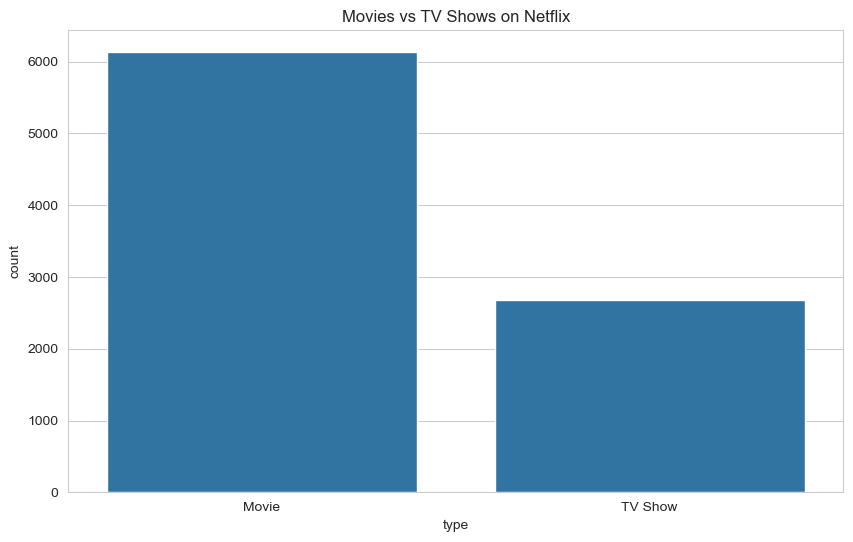

In [24]:
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows on Netflix")
plt.savefig("images/movies_vs_tvshows.png", bbox_inches='tight')
plt.show()

In [25]:
top_countries = df['country'].value_counts().head(10)
top_countries

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

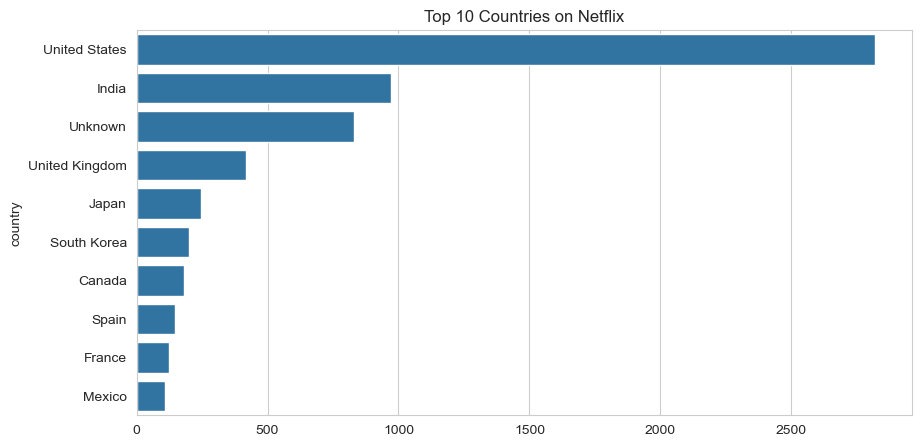

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries on Netflix")
plt.savefig("images/top_countries.png", bbox_inches='tight')
plt.show()

In [27]:
year_trend = df['year_added'].value_counts().sort_index()
year_trend

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1889
2021    1498
Name: count, dtype: int64

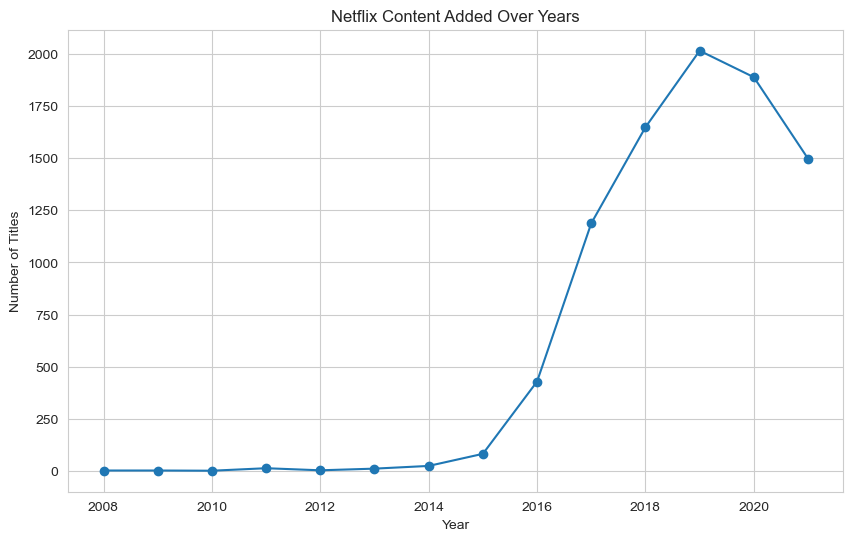

In [28]:
plt.plot(year_trend.index, year_trend.values, marker='o')
plt.title("Netflix Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.savefig("images/content_by_year.png", bbox_inches='tight')
plt.show()

## 📊 EDA Insights

- Movies are more than TV Shows...
- US contributes the highest content...
- 2021 had the highest content addition...

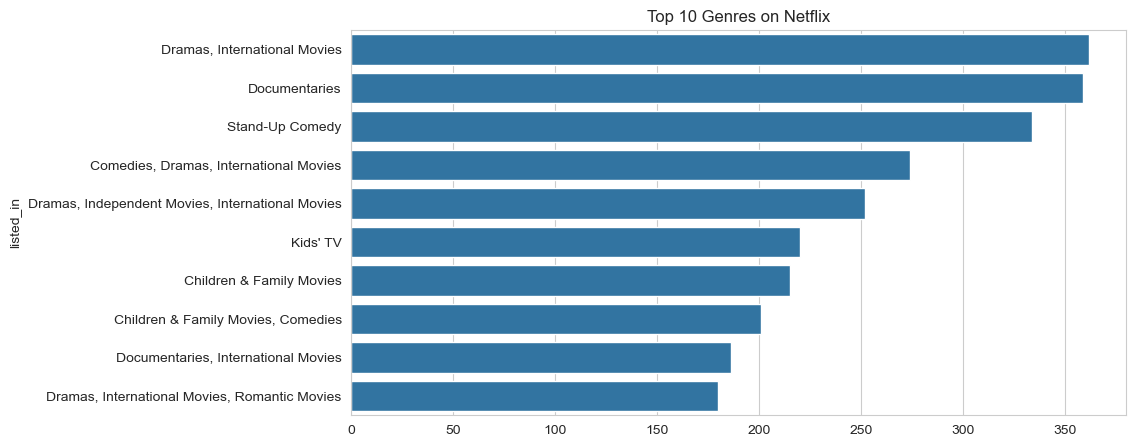

In [29]:
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.savefig("images/top_genres.png", bbox_inches='tight')
plt.show()

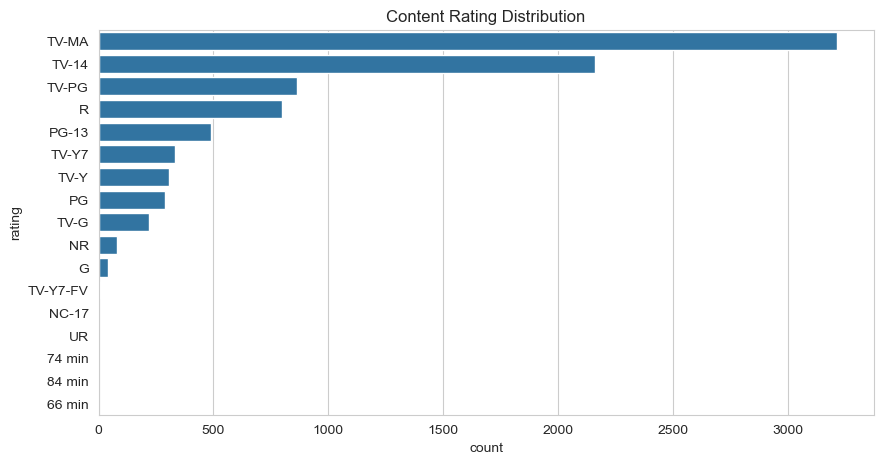

In [30]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating', data=df,order=df['rating'].value_counts().index)

plt.title("Content Rating Distribution")
plt.savefig("images/rating_distribution.png", bbox_inches='tight')
plt.show()

In [31]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

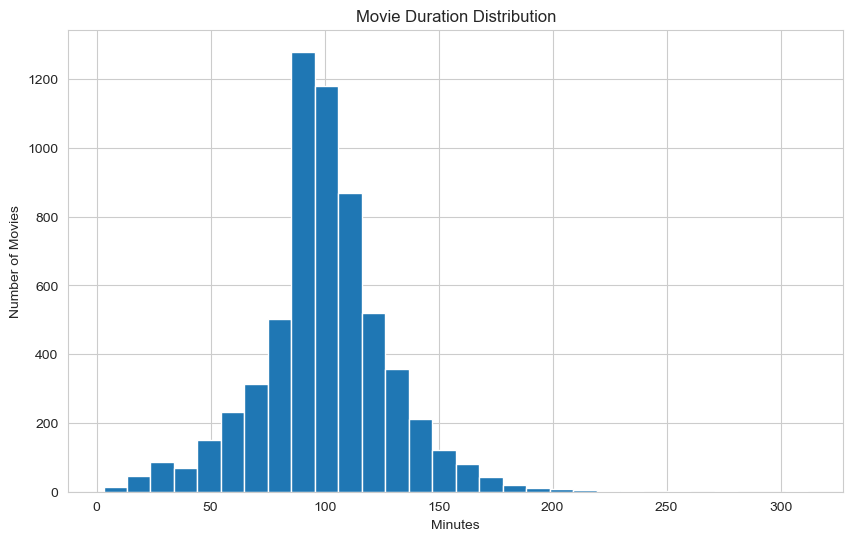

np.float64(99.57718668407311)

In [32]:
plt.hist(movies['duration'].dropna(), bins=30)
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Number of Movies")
plt.savefig("images/movie_duration.png", bbox_inches='tight')
plt.show()
movies['duration'].mean()

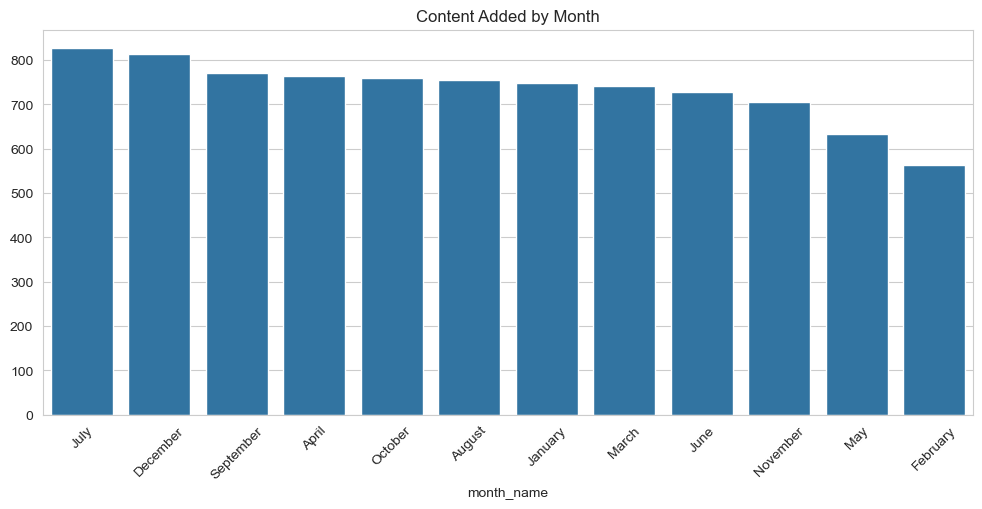

In [33]:
monthly = df['month_name'].value_counts()

plt.figure(figsize=(12,5))
sns.barplot(x=monthly.index, y=monthly.values)
plt.title("Content Added by Month")
plt.xticks(rotation=45)
plt.show()

## 📊 Exploratory Data Analysis (EDA) Insights

- The most common genres on Netflix are **Dramas and International Movies**, showing a strong focus on storytelling and global content.

- The majority of content is rated **TV-MA**, indicating that Netflix primarily targets a mature audience (18+).

- The average movie duration is approximately **100 minutes**, which aligns with standard feature film lengths.

- Netflix content is diverse but leans heavily toward entertainment-driven and adult-oriented programming.